<small>
Introducción a la Ciencia de Datos | Posgrado en Ciencias de la Computación — CICESE  
Tarea 3: Calidad de vino tinto
</small>

---


# Tarea 3: Notebook de regresion (calidad de vino tinto)

## 1. Descripcion del dataset

El análisis utiliza el archivo `winequality-red.csv`, que contiene el perfil fisicoquímico y la calidad sensorial de vinos tintos. Este dataset fue creado en el 2009 y es publico para fines educativos y de investigacion.

- **Dataset:** Wine Quality 
- **Autor:** P. Cortez, A. Cerdeira, F. Almeida, T. Matos and J. Reis.
- **Fuente:** https://archive.ics.uci.edu/dataset/186/wine+quality
- **Fecha de acceso:** 05/10/2026

### Estructura del dataset

La estructura del dataset esta definida en el archivo `winequality.names` donde se establece que las etiquetas del archivo son las siguientes:

| N.º | Variable | Tipo de variable | Método / Origen |
|--:|:--|:--|:--|
| 1 | fixed acidity | Entrada | Pruebas fisicoquimicas |
| 2 | volatile acidity | Entrada | Pruebas fisicoquimicas |
| 3 | citric acid | Entrada | Pruebas fisicoquimicas |
| 4 | residual sugar | Entrada | Pruebas fisicoquimicas |
| 5 | chlorides | Entrada | Pruebas fisicoquimicas |
| 6 | free sulfur dioxide | Entrada | Pruebas fisicoquimicas |
| 7 | total sulfur dioxide | Entrada | Pruebas fisicoquimicas |
| 8 | density | Entrada | Pruebas fisicoquimicas |
| 9 | pH | Entrada | Pruebas fisicoquimicas |
| 10 | sulphates | Entrada | Pruebas fisicoquimicas |
| 11 | alcohol | Entrada | Pruebas fisicoquimicas |
| 12 | quality | Salida | Datos sensoriales (puntuacion de 0 a 10) |


### 1.1 Carga de datos

In [112]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path

data_dir = Path("../../../Datos/wine quality")

path_1 = data_dir / "winequality-red.csv"

df_1 = pd.read_csv(path_1, sep=";")
df_1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [113]:
df_1.shape

(1599, 12)

### 1.2 Configuracion de estilos y semilla

Con esta parte establecemos el estilo visual para todos los graficos que se generaran en este archivo. Definimos tambien una constante para la **semilla** de numeros aleatorios con el fin de *garantizar que los resultados de experimentos sean reproductibles*.

In [114]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
NARANJA = "#E76A28"     
GRIS = "#5B6584"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlecolor": AZUL_OSCURO,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelcolor": AZUL_OSCURO,
    "axes.edgecolor": "#C9CFDF",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E6EF",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "legend.frameon": False,
})

SEMILLA = 42

---

## 2. Estado inicial del dataset

Se comprueba que nuestro dataset cumpla con las observaciones que se describen en el archivo `winequality.names`. En este archivo se especifica a **ausencia de valores nulos por atributo**. 

### 2.1 Valores nulos

In [115]:
nulos = df_1.isnull().sum()
porcentaje = df_1.isnull().mean() *100
pd.DataFrame({
    "nulos": nulos,
    "%": porcentaje.round()
}).query("nulos> 0")

,nulos,%


### 2.2 Estadisticos descriptivos

In [116]:
df_1.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


---

## 3. Analisis exploratorio

### 3.1 Distribución de la variable objetivo `quality`

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


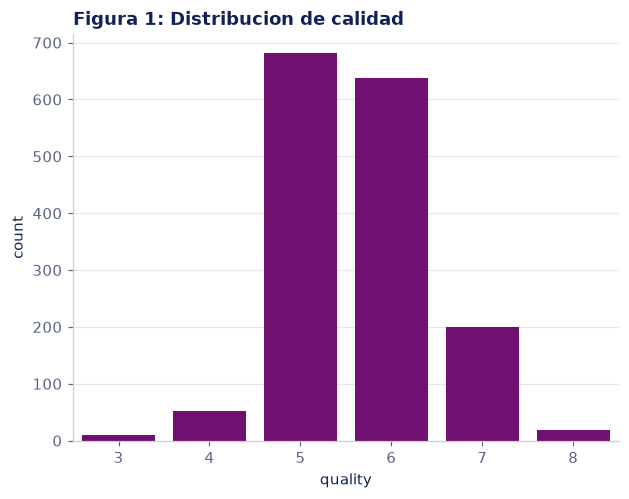

In [117]:
print(df_1["quality"].value_counts())

sns.countplot(data=df_1, x="quality", color="purple")
plt.title("Figura 1: Distribucion de calidad")
plt.savefig("Images/Figura 1 - Distribucion de calidad", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Correlacion de cada variable con `quality`

In [118]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


X = df_1.drop(columns=["quality"])
y = df_1["quality"]

correlaciones = X.corrwith(y).sort_values(ascending=False).round(2)
print(correlaciones)

alcohol                 0.48
sulphates               0.25
citric acid             0.23
fixed acidity           0.12
residual sugar          0.01
free sulfur dioxide    -0.05
pH                     -0.06
chlorides              -0.13
density                -0.17
total sulfur dioxide   -0.19
volatile acidity       -0.39
dtype: float64


### 3.3 Recta de minimos cuadrados con `alcohol`

Se ajusta una recta usando solo `alcohol`, la variable mas correlacionada con `quality`. Es unicamente exploratoria: el modelo de la sección 4 usa las 11 variables.

In [127]:
x = df_1["alcohol"].to_numpy()  
y_obs = df_1["quality"].to_numpy()  


theta1_alcohol = np.sum((x - x.mean()) * (y_obs - y_obs.mean())) / np.sum(
    (x - x.mean()) ** 2
)
theta0_alcohol = y_obs.mean() - theta1_alcohol * x.mean()

print(f"θ0 (Intercepto) = {theta0_alcohol:.2f}")
print(f"θ1 (Pendiente)  = {theta1_alcohol:.3f}")

θ0 (Intercepto) = 1.87
θ1 (Pendiente)  = 0.361


**Interpretacion de la recta**

La recta describe como cambia la calidad del vino conforme aumenta el **alcohol**, la variable mas correlacionada con `quality`:

$$\widehat{\text{quality}} = 1.87 + 0.361 \cdot \text{alcohol}$$

- **Pendiente ($\theta_1$ = 0.361):** por cada 1 % adicional de alcohol, la calidad aumenta **en promedio 0.36 puntos**.
- **Signo positivo:** indica una **relacion directa** entre la graduacion alcoholica y la calidad: los vinos con mas alcohol tienden a recibir mejores calificaciones.

In [128]:
x = df_1["volatile acidity"].to_numpy()  
y_obs = df_1["quality"].to_numpy()  


theta1_acidez = np.sum((x - x.mean()) * (y_obs - y_obs.mean())) / np.sum(
    (x - x.mean()) ** 2
)
theta0_acidez = y_obs.mean() - theta1_acidez * x.mean()

print(f"θ0 (Intercepto) = {theta0_acidez:.2f}")
print(f"θ1 (Pendiente)  = {theta1_acidez:.3f}")

θ0 (Intercepto) = 6.57
θ1 (Pendiente)  = -1.761


**Interpretacion de la recta**

La recta describe como cambia la calidad del vino conforme aumenta la **acidez volatil**, la variable con la correlacion negativa mas fuerte con `quality` (r = −0.39):

$$\widehat{\text{quality}} = 6.57 - 1.761 \cdot \text{volatile acidity}$$

- **Pendiente ($\theta_1$ = −1.761):** por cada 1 g/dm³ adicional de acidez volatil, la calidad disminuye **en promedio 1.76 puntos**. Como la acidez volatil va de 0.12 a 1.58 g/dm³, es mas util verlo en pasos pequenos: cada **0.1 g/dm³** adicional reduce la calidad en promedio **0.18 puntos**.
- **Signo negativo:** indica una **relacion inversa**, los vinos con mas acidez volatil tienden a recibir peores calificaciones. Esto tiene sentido, porque la acidez volatil se debe principalmente al acido acetico, que en exceso da al vino un sabor y olor a vinagre.

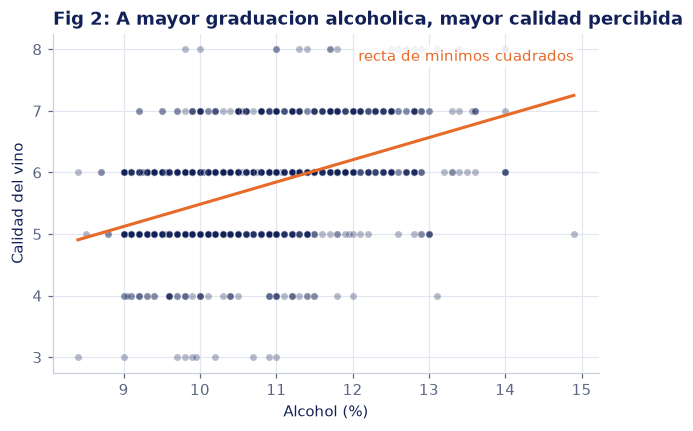

In [129]:
x = df_1["alcohol"].to_numpy()
y_obs = df_1["quality"].to_numpy()

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.scatter(x, y_obs, s=22, color=AZUL_OSCURO, alpha=0.3, edgecolor="white", linewidth=0.5)
malla = np.linspace(x.min(), x.max(), 100)
ax.plot(malla, theta0_alcohol + theta1_alcohol * malla, color=NARANJA, linewidth=2)

ax.text(
    malla[-1],
    y_obs.max(),
    "recta de minimos cuadrados",
    color=NARANJA,
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.2", 
        facecolor="white", 
        edgecolor="none", 
        alpha=0.85
    )
)

ax.set_xlabel("Alcohol (%)")
ax.set_ylabel("Calidad del vino")
ax.set_title("Fig 2: A mayor graduacion alcoholica, mayor calidad percibida")

plt.savefig("Images/Figura 2 - A mayor graduacion alcoholica, mayor calidad percibida.png", dpi=150, bbox_inches="tight")
plt.show()


---

## 4. Regresión: predecir `quality`

### 4.1 Partición 80/20, ajuste y comparación con predecir siempre el promedio

In [130]:
X = df_1.drop(columns=["quality"])
y = df_1["quality"]

#Split de train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA
)

clasificador_linear = LinearRegression()
clasificador_linear.fit(X_train, y_train)

y_pred_reg = clasificador_linear.predict(X_test)

rmse_lineal = np.sqrt(mean_squared_error(y_test, y_pred_reg))
score_r2 = r2_score(y_test, y_pred_reg)

mean_train = y_train.mean()
y_pred_base_reg = np.full(len(y_test), mean_train)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base_reg))
r2_base = r2_score(y_test, y_pred_base_reg)


print("--- RESULTADOS DE REGRESION ---")
print(f"Modelo Lineal  -> RMSE: {rmse_lineal:.4f} | R^2: {score_r2:.4f}")
print(f"Linea de Base  -> RMSE: {rmse_base:.4f} | R^2: {r2_base:.4f}")

--- RESULTADOS DE REGRESION ---
Modelo Lineal  -> RMSE: 0.6245 | R^2: 0.4032
Linea de Base  -> RMSE: 0.8107 | R^2: -0.0056


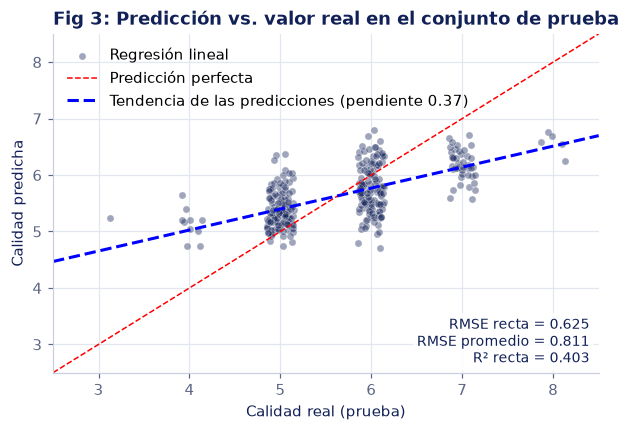

In [ ]:
rng = np.random.default_rng(SEMILLA)
y_real_jitter = y_test + rng.uniform(-0.15, 0.15, len(y_test))

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.scatter(y_real_jitter, y_pred_reg, s=22, color=AZUL_OSCURO, alpha=0.4, edgecolor="white", linewidth=0.5, label="Regresión lineal")

lims = (y_test.min() - 0.5, y_test.max() + 0.5)
ax.plot(lims, lims, color="red", linestyle="--", linewidth=1, label="Predicción perfecta")


pend, inter = np.polyfit(y_test, y_pred_reg, 1)
malla = np.array(lims)
ax.plot(malla, inter + pend * malla, color="blue", linestyle="--", linewidth=2, label=f"Tendencia de las predicciones (pendiente {pend:.2f})")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Calidad real (prueba)")
ax.set_ylabel("Calidad predicha")
ax.set_title("Fig 3: Predicción vs. valor real en el conjunto de prueba")
ax.legend(loc="upper left")

ax.text(
    lims[1] - 0.1, lims[0] + 0.1,
    f"RMSE recta = {rmse_lineal:.3f}\nRMSE promedio = {rmse_base:.3f}\nR² recta = {score_r2:.3f}",
    ha="right", va="bottom", color=AZUL_OSCURO, fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.85)
)

plt.savefig("Images/Figura 3 - Prediccion vs valor real.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Interpretacion

**Particion de los datos**

Con la particion 80/20 se divide el total de los 1599 vinos en dos grupos:

```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMILLA)
```

- **Entrenamiento (80 %, 1279 vinos):** el modelo los utiliza para estimar los coeficientes con `lr_reg.fit(X_train, y_train)`. Los coeficientes son los numeros que determinan la dirección e intensidad del efecto de cada variable independiente $(X)$ sobre la variable dependiente $(y)$. Al ajustar el modelo se calcula la ecuación lineal que mejor se ajusta a los datos de entrenamiento mediante **minimos cuadrados**.
- **Prueba (20 %, 320 vinos):** el modelo nunca los vio durante el ajuste; se usan unicamente para evaluar que tan bien predice datos nuevos.

**Resultados en el conjunto de prueba**

| Modelo | RMSE | $R^2$ |
| :--- | :---: | :---: |
| Regresion lineal | 0.6245 | 0.4032 |
| Siempre el promedio (línea base) | 0.8107 | −0.0056 |

**Regresion lineal**

- **RMSE = 0.62:** en promedio, las predicciones del modelo se desvian aproximadamente **0.62 puntos** de calidad respecto al valor real.
- **$R^2$ = 0.40:** las variables fisicoquimicas $(X)$ logran explicar alrededor del **40 %** de la variabilidad en la calidad del vino $(y)$.

**Linea base: predecir siempre el promedio**

- **RMSE = 0.81:** si a todos los vinos les asignaramos la calidad promedio del entrenamiento (5.62), sin usar ninguna variable, nos equivocariamos en promedio **0.81 puntos** de calidad.
- **$R^2$ ≈ 0:** predecir siempre el promedio no explica nada de la variabilidad, como era de esperarse. El valor es ligeramente negativo porque el promedio proviene del entrenamiento y no coincide exactamente con el de prueba.

**Comparación**

La regresion lineal reduce el RMSE de **0.81 a 0.62** (alrededor de un 23 % menos de error) y pasa de un $R^2$ de 0 a 0.40. Esto indica que las variables fisicoquimicas **si aportan informacion** para predecir la calidad del vino. Sin embargo, la relacion es **moderada**: el 60 % de la variabilidad queda sin explicar, por lo que el modelo es util pero esta lejos de ser preciso.

---

## 5. Clasificacion: bueno = `quality` ≥ 7

### 5.1 Variable binaria y ajuste de la misma regresion

In [123]:
y_bueno = (df_1["quality"] >= 7).astype(int)

yb_train = y_bueno.loc[X_train.index]
yb_test = y_bueno.loc[X_test.index]

print(f"Vinos buenos en entrenamiento: {yb_train.sum()} de {len(yb_train)} ({yb_train.mean(): .1%})")
print(f"Vinos buenos en prueba: {yb_test.sum()} de {len(yb_test)} ({yb_test.mean(): .1%})")

calsificador_lineal = LinearRegression()
calsificador_lineal.fit(X_train, yb_train)

yb_gorrito = calsificador_lineal.predict(X_test)
yb_predicho = (yb_gorrito >= 0.5).astype(int)

Vinos buenos en entrenamiento: 170 de 1279 ( 13.3%)
Vinos buenos en prueba: 47 de 320 ( 14.7%)


**Creacion de la variable binaria**

En el codigo anterior se crea la variable `bueno` a partir de `quality`:

- Si la calidad del vino es **mayor o igual a 7**, se clasifica como **«bueno»**; de lo contrario, como **«no bueno»**.
- La comparación `df_1["quality"] >= 7` produce valores booleanos, que `.astype(int)` convierte a números:
  - **True → 1** (bueno)
  - **False → 0** (no bueno)
- Con `.loc[X_train.index]` y `.loc[X_test.index]` se usan los **mismos indices de la particion 80/20** de la sección 4 para dividir la nueva variable binaria. Asi, la clasificacion se entrena y se evalua con exactamente los mismos vinos que la regresion, lo que permite comparar ambos problemas de forma justa.

### 5.2 Porcentaje de aciertos, comparacion con «no bueno» y y fuera de [0, 1]

In [131]:
acc_recta = accuracy_score(yb_test, yb_predicho)
yb_predicho_base = np.zeros(len(yb_test), dtype=int)
acc_base = accuracy_score(yb_test, yb_predicho_base)

fuera= ((yb_gorrito < 0) | (yb_gorrito > 1)).sum()

print("--- RESULTADOS DE CLASIFICACION ---")
print(f"Recta (y ≥ 0.5)     -> Aciertos: {acc_recta:.2%}")
print(f"Siempre 'no bueno'  -> Aciertos: {acc_base:.2%}")
print(f"y fuera de [0, 1]: {fuera} de {len(yb_gorrito)}  "
      f"(menores a 0: {(yb_gorrito < 0).sum()}, mayores a 1: {(yb_gorrito > 1).sum()})")
print(f"Rango de y: [{yb_gorrito.min():.2f}, {yb_gorrito.max():.2f}]")
print(f"Vinos clasificados como 'bueno': {yb_predicho.sum()} (realmente buenos: {yb_test.sum()})")

--- RESULTADOS DE CLASIFICACION ---
Recta (y ≥ 0.5)     -> Aciertos: 86.25%
Siempre 'no bueno'  -> Aciertos: 85.31%
y fuera de [0, 1]: 82 de 320  (menores a 0: 82, mayores a 1: 0)
Rango de y: [-0.15, 0.54]
Vinos clasificados como 'bueno': 7 (realmente buenos: 47)


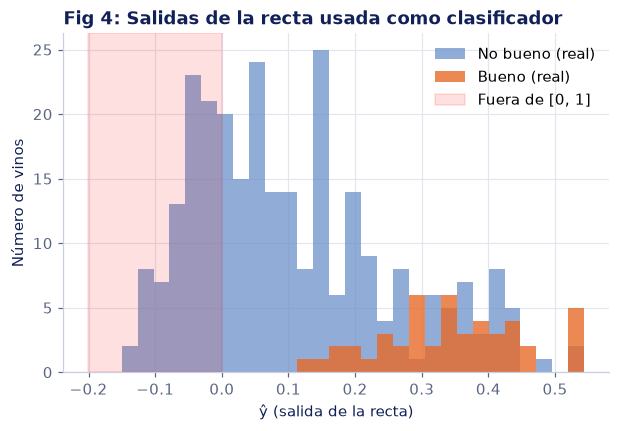

In [138]:
bins = np.linspace(yb_gorrito.min(), yb_gorrito.max(), 30)

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.hist(yb_gorrito[yb_test == 0], bins=bins, color=AZUL, alpha=0.8, label="No bueno (real)")
ax.hist(yb_gorrito[yb_test == 1], bins=bins, color=NARANJA, alpha=0.8, label="Bueno (real)")
ax.axvspan(yb_gorrito.min() - 0.05, 0, color="red", alpha=0.12, label="Fuera de [0, 1]")

ax.set_xlabel("ŷ (salida de la recta)")
ax.set_ylabel("Número de vinos")
ax.set_title("Fig 4: Salidas de la recta usada como clasificador")
ax.legend(loc="upper right")

plt.savefig("Images/Figura 4 - Salidas de la recta como clasificador.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Interpretacion

La regresion lineal **no es adecuada para clasificar**, porque predice valores continuos sin acotar en lugar de categorias o probabilidades entre 0 y 1. La recta puede arrojar resultados **mayores que 1 o menores que 0**, lo cual no tiene sentido al buscar una probabilidad o una clase binaria. En nuestros datos, **82 de las 320 predicciones** en prueba quedaron por debajo de 0.

---

## 6. Conclusion



La regresion lineal es una excelente herramienta para predecir valores numericos continuos, pero falla al intentar resolver problemas de clasificacion. Los resultados de este trabajo lo demuestran claramente por tres razones:

- **Rango de salida y sentido:** para evaluar la calidad de vino la regresion lineal redujo el error de prediccion (RMSE de 0.81 a 0.62) y explico el 40% de la varaivion ($R^2$ = 0.40). En cambio, al intentar calsificar si un vino es "bueno" o "no es bueno", el modelo entrego valores negativos de hasta $-0.15$. Como una propabilidad no puede ser menor a 0% ni mayor a 100%, una recta sin limites carece de sentido para clasificar.

- **Sensibilidad al desbalance:** Como solo el 14% de los vinos eran de alta calidad, la recta se atrajo hacia el grupo mayoritario y comprimio casi todas las predicciones por debajo de 0.54. Esto provoco que el modelo solo identificara 7 de los 47 vinos buenos reales.

La regresion lineal funciona cuando buscamos estimar una **magnitud**, pero resulta inadecuada para definir **categorias**.

## Extras y Declaracion de uso de IA

Se utilizo un modelo de **inteligencia artificial (Google Gemini, Flash 3.6)** como asistente en la revision, edicion y optimizacion del formato Markdown de este Notebook.

Tambien se utilizo un modelo de **inteligencia artificial (Athropic, Calude Opus 5.5)** como asistente para organizar la estructura del notebook; revisar y depurar codigo.